In [236]:
!pip install tensorflow_datasets

In [237]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout,BatchNormalization
from tensorflow.keras.models import Sequential
import os
import tensorflow_datasets as tfds
import tensorflow as tf

In [238]:
dataset, info = tfds.load('horses_or_humans', with_info=True, as_supervised=True)

In [239]:
class_names=info.features['label'].names
class_names

['horses', 'humans']

In [240]:
#creating a directory
for i, example in enumerate(dataset['train']):
  # example = (image, label)
  image, label = example
  save_dir = './horses_or_humans/train/{}'.format(class_names[label])
  os.makedirs(save_dir, exist_ok=True)

  filename = save_dir + "/" + "{}_{}.jpg".format(class_names[label], i)
  tf.keras.preprocessing.image.save_img(filename, image.numpy())
  # print(filename)
  # break

array([[[134, 119, 110],
        [134, 119, 110],
        [134, 119, 110],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[135, 120, 111],
        [135, 120, 111],
        [135, 120, 111],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[135, 119, 112],
        [136, 120, 113],
        [136, 120, 113],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[ 43,  45,  53],
        [ 47,  49,  57],
        [ 47,  49,  57],
        ...,
        [ 55,  59,  70],
        [ 60,  63,  77],
        [ 66,  69,  83]],

       [[ 47,  48,  58],
        [ 52,  53,  63],
        [ 54,  55,  65],
        ...,
        [ 51,  55,  66],
        [ 56,  59,  73],
        [ 60,  63,  77]],

       [[ 46,  47,  57],
        [ 52,  53,  63],
        [ 56,  57,  67],
        ...,
        [ 49,  53,  64],
        [ 53,  56,  70],
        [ 56,  59,  73]]], dtype=uint8)
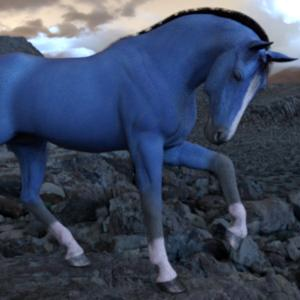

In [241]:
import cv2
horse = cv2.imread('/content/horses_or_humans/train/horses/horses_1000.jpg')
horse

array([[[176, 192, 204],
        [176, 192, 204],
        [177, 193, 205],
        ...,
        [151, 170, 185],
        [150, 169, 184],
        [149, 168, 183]],

       [[178, 194, 206],
        [177, 193, 205],
        [175, 191, 203],
        ...,
        [153, 172, 187],
        [152, 171, 186],
        [151, 170, 185]],

       [[178, 194, 206],
        [176, 192, 204],
        [173, 189, 201],
        ...,
        [151, 170, 185],
        [150, 169, 184],
        [149, 168, 183]],

       ...,

       [[197, 219, 231],
        [194, 216, 228],
        [181, 203, 215],
        ...,
        [147, 163, 175],
        [151, 167, 179],
        [148, 164, 176]],

       [[199, 221, 233],
        [194, 216, 228],
        [179, 201, 213],
        ...,
        [129, 145, 157],
        [137, 153, 165],
        [140, 156, 168]],

       [[191, 213, 225],
        [191, 213, 225],
        [182, 204, 216],
        ...,
        [118, 134, 146],
        [126, 142, 154],
        [131, 147, 159]]], dtype=uint8)
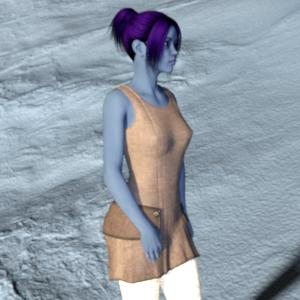

In [242]:
humans = cv2.imread('/content/horses_or_humans/train/humans/humans_115.jpg')
humans

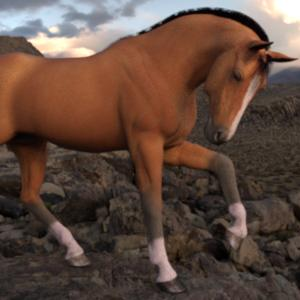

In [243]:
from google.colab.patches import cv2_imshow
cv2_imshow(horse)

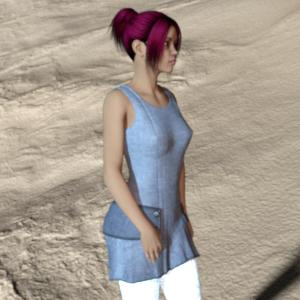

In [244]:
from google.colab.patches import cv2_imshow
cv2_imshow(humans)

In [245]:
datagen = ImageDataGenerator(rescale=1./255,validation_split=0.2,rotation_range=10,
                             width_shift_range=0.1,height_shift_range=0.1,
                             shear_range=0.1,zoom_range=0.1,horizontal_flip=True)
datagen

In [246]:
train_generator = datagen.flow_from_directory('/content/horses_or_humans/train',target_size=(150,150),batch_size=32,
                                              class_mode='binary',subset='training')

Found 822 images belonging to 2 classes.


In [247]:
validation_generator = datagen.flow_from_directory('/content/horses_or_humans/train',target_size = (150,150),batch_size=32,
                                                   class_mode='binary',subset='validation')

Found 205 images belonging to 2 classes.


In [248]:
model = Sequential()
model.add(Conv2D(64,kernel_size=3,activation='relu',input_shape=(150,150,3)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Dropout(0.2))#1st layer

model.add(Conv2D(128,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Dropout(0.2))#2nd layer

#3rd Layer CNN
model.add(Conv2D(256,kernel_size=3,activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [249]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 74, 74, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 72, 72, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 36, 36, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 36, 36, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 36, 36, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 34, 34, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 17, 17, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 17, 17, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 17, 17, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 73984)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 512)            │    37,880,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,384,513 (146.43 MB)

 Trainable params: 38,383,617 (146.42 MB)

 Non-trainable params: 896 (3.50 KB)

In [250]:
# import shutil

# # Zip the created directory
# shutil.make_archive('horses_or_humans_dataset', 'zip', './horses_or_humans')

In [251]:
dataset, info = tfds.load('horses_or_humans', with_info=True, as_supervised=True)

In [252]:
#creating a directory
for i, example in enumerate(dataset['train']):
  # example = (image, label)
  image, label = example
  save_dir = './horses_or_humans/train/{}'.format(class_names[label])
  os.makedirs(save_dir, exist_ok=True)

  filename = save_dir + "/" + "{}_{}.jpg".format(class_names[label], i)
  tf.keras.preprocessing.image.save_img(filename, image.numpy())
  # print(filename)
  # break

In [253]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_30 (Conv2D)              │ (None, 148, 148, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 74, 74, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_44 (Dropout)            │ (None, 74, 74, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 72, 72, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_28 (MaxPooling2D) │ (None, 36, 36, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 36, 36, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_45 (Dropout)            │ (None, 36, 36, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 34, 34, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_29 (MaxPooling2D) │ (None, 17, 17, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 17, 17, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_46 (Dropout)            │ (None, 17, 17, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_12 (Flatten)            │ (None, 73984)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 512)            │    37,880,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,384,513 (146.43 MB)

 Trainable params: 38,383,617 (146.42 MB)

 Non-trainable params: 896 (3.50 KB)

**Training-Epoch✅**

In [261]:
from IPython.core import history
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.0001)
history = model.fit(train_generator, epochs=50, validation_data=validation_generator, callbacks=[early_stop, reduce_lr])
history.history

Epoch 1/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 294ms/step - accuracy: 0.9611 - loss: 0.5213 - val_accuracy: 0.5122 - val_loss: 3.5314 - learning_rate: 0.0010
Epoch 2/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 274ms/step - accuracy: 0.9513 - loss: 1.2885 - val_accuracy: 0.5122 - val_loss: 16.7380 - learning_rate: 0.0010
Epoch 3/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 290ms/step - accuracy: 0.9465 - loss: 1.2359 - val_accuracy: 0.5122 - val_loss: 4.4228 - learning_rate: 0.0010
Epoch 4/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 271ms/step - accuracy: 0.9672 - loss: 0.5356 - val_accuracy: 0.5122 - val_loss: 20.2129 - learning_rate: 0.0010
Epoch 5/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 305ms/step - accuracy: 0.9769 - loss: 0.3006 - val_accuracy: 0.5122 - val_loss: 17.8924 - learning_rate: 2.0000e-04
Epoch 6/50
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 242ms/step - accuracy: 0.9842 - loss: 0.1611 - val_accuracy: 0.5122 - val_loss: 17.5516 - learning_rate: 2.0000e-04


{'accuracy': [0.9610705375671387,
  0.9513381719589233,
  0.9464720487594604,
  0.9671533107757568,
  0.9768856167793274,
  0.9841849207878113],
 'loss': [0.5212814807891846,
  1.288543939590454,
  1.23588228225708,
  0.5356186032295227,
  0.3006265163421631,
  0.16109071671962738],
 'val_accuracy': [0.5121951103210449,
  0.5121951103210449,
  0.5121951103210449,
  0.5121951103210449,
  0.5121951103210449,
  0.5121951103210449],
 'val_loss': [3.531386137008667,
  16.738008499145508,
  4.42284631729126,
  20.212942123413086,
  17.892427444458008,
  17.551639556884766],
 'learning_rate': [0.0010000000474974513,
  0.0010000000474974513,
  0.0010000000474974513,
  0.0010000000474974513,
  0.00020000000949949026,
  0.00020000000949949026]}

In [255]:
#save model
model.save('Horses and Humans.h5')

In [256]:
model_load=tf.keras.models.load_model('Horses and Humans.h5')

In [257]:
import requests
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing import image

# 🔹 Provide a direct image URL
img_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcRQGo2b2lkeRSepWCPr7CIYjv_9AlZwZo-Okg&s"
img = Image.open(requests.get(img_url, stream=True).raw).convert("RGB").resize((150, 150))

# 🔹 Convert to array
img_array = image.img_to_array(img)

# 🔹 Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# 🔹 Normalize (FIXED: normalize img_array, not img)
img_array = img_array / 255.0

# 🔹 Predict (FIXED: use img_array)
prediction = model.predict(img_array)

# 🔹 Binary classification
TH = 0.5
prediction = int(prediction[0][0] > TH)

# 🔹 Class labels
classes = {v: k for k, v in train_generator.class_indices.items()}

print(classes[prediction])

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 576ms/step
horses


In [262]:
import requests
import numpy as np
from PIL import Image
from tensorflow.keras.preprocessing import image

# 🔹 Provide a direct image URL
img_url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcQhQ2L8P5B4PjGv1W3l0d0q8sY1t6h2s6X1fQ&s"
# 🔹 Load and resize image
img = Image.open(requests.get(img_url, stream=True).raw).convert("RGB").resize((150, 150))

# 🔹 Convert to array
img_array = image.img_to_array(img)

# 🔹 Expand dimensions
img_array = np.expand_dims(img_array, axis=0)

# 🔹 Normalize (FIXED: normalize img_array, not img)
img_array = img_array / 255.0

# 🔹 Predict (FIXED: use img_array)
prediction = model.predict(img_array)

# 🔹 Binary classification
TH = 0.5
prediction = int(prediction[0][0] > TH)

# 🔹 Class labels
classes = {v: k for k, v in train_generator.class_indices.items()}

print(classes[prediction])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
humans
